<a href="https://colab.research.google.com/github/MoSahil147/DeepFake-Detection-in-Online-Social-Network-OSN-Using-Advanced-Machine-Learning/blob/main/Design_Project_DeepFake_Detection_in_Online_Social_Network_(OSN)_Using_Advanced_Machine_Learning_Sahil_Mohapatra_(2022A7PS0112U).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile, os

zip_path = "/content/drive/MyDrive/DeepFake Datasets/FakeAVCeleb_v1.2.zip"
extract_path = "/content/FakeAVCeleb_v1.2"

print("Unzipping dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Extraction complete! Files extracted to: {extract_path}")

Unzipping dataset...
Extraction complete! Files extracted to: /content/FakeAVCeleb_v1.2


In [ ]:
for root, dirs, files in os.walk(extract_path):
    print(f"Folder: {root}")
    print(f"Subfolders: {dirs}")
    print(f"Files (sample): {files[:5]}")
    break  # Only top level

Folder: /content/FakeAVCeleb_v1.2
Subfolders: ['FakeAVCeleb_v1.2']
Files (sample): []


In [ ]:
!pip install opencv-python moviepy torch torchvision librosa

In [ ]:
import subprocess

video_dir = "/content/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2"
audio_output_dir = "/content/audio_clips"
os.makedirs(audio_output_dir, exist_ok=True)

def collect_video_paths(base_path):
    paths = []
    for root, _, files in os.walk(base_path):
        for file in files:
            if file.endswith(".mp4"):
                paths.append(os.path.join(root, file))
    return paths

# Collect paths
real_videos = collect_video_paths(os.path.join(video_dir, "RealVideo-RealAudio"))
fake_videos = collect_video_paths(os.path.join(video_dir, "FakeVideo-RealAudio"))

# Extraction function
def extract_audio_batch(videos, category):
    count, errors = 0, []
    for i, video_path in enumerate(videos):
        rel = os.path.relpath(video_path, video_dir)
        audio_path = os.path.join(audio_output_dir, rel.replace(".mp4", ".wav"))
        os.makedirs(os.path.dirname(audio_path), exist_ok=True)

        print(f"🔊 [{category}] ({i+1}/{len(videos)}): {os.path.basename(video_path)}")
        cmd = ["ffmpeg", "-i", video_path, "-q:a", "0", "-map", "a", audio_path, "-y"]
        try:
            subprocess.run(cmd, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            count += 1
        except subprocess.CalledProcessError:
            print(f" Failed: {video_path}")
            errors.append(video_path)
    return count, errors

# Extract
real_count, real_err = extract_audio_batch(real_videos, "Real")
fake_count, fake_err = extract_audio_batch(fake_videos, "Fake")

print(f"\n Audio Extraction Done!")
print(f" Real: {real_count} | Fake: {fake_count}")
print(f" Errors: {len(real_err) + len(fake_err)}")

Streaming output truncated to the last 5000 lines.
🔊 [Fake] (4714/9709): 00135_id05845_XfMHm6CEwPw.mp4
🔊 [Fake] (4715/9709): 00135_id06752_wavtolip.mp4
🔊 [Fake] (4716/9709): 00135_id05920_wavtolip.mp4
🔊 [Fake] (4717/9709): 00021_id07136_4e43eS5p3_M.mp4
🔊 [Fake] (4718/9709): 00021_id05931_wavtolip.mp4
🔊 [Fake] (4719/9709): 00021_id03559_pgetxl1qbzM.mp4
🔊 [Fake] (4720/9709): 00021_id00417_GhIZam3v09g.mp4
🔊 [Fake] (4721/9709): 00021_id07689_wavtolip.mp4
🔊 [Fake] (4722/9709): 00021_id03559_wavtolip.mp4
🔊 [Fake] (4723/9709): 00021_id00043_wavtolip.mp4
🔊 [Fake] (4724/9709): 00021_id04070_wavtolip.mp4
🔊 [Fake] (4725/9709): 00021_id07236_wavtolip.mp4
🔊 [Fake] (4726/9709): 00021_id05435_OvX-Jv_whcU.mp4
🔊 [Fake] (4727/9709): 00021_id00149_s2evR-nUhVY.mp4
🔊 [Fake] (4728/9709): 00021_id04530_wavtolip.mp4
🔊 [Fake] (4729/9709): 00021_id04529_S92uo-UShxE.mp4
🔊 [Fake] (4730/9709): 00021_id04490_G00MMIdUOTc.mp4
🔊 [Fake] (4731/9709): 00021_id06268_wavtolip.mp4
🔊 [Fake] (4732/9709): 00021_id04529_wavtoli

In [ ]:
frame_output_dir = "/content/video_frames"
os.makedirs(frame_output_dir, exist_ok=True)

all_videos = real_videos + fake_videos
errors = []

for idx, video_path in enumerate(all_videos):
    rel_path = os.path.relpath(video_path, video_dir)
    frame_folder = os.path.join(frame_output_dir, rel_path.replace(".mp4", ""))
    os.makedirs(frame_folder, exist_ok=True)

    print(f"\n [{idx+1}/{len(all_videos)}] Extracting frames from: {os.path.basename(video_path)}")
    cmd = [
        "ffmpeg", "-i", video_path, "-vf", "fps=1",
        os.path.join(frame_folder, "frame_%04d.jpg")
    ]
    try:
        subprocess.run(cmd, check=True)
        print(f" Frames saved in: {frame_folder}")
    except subprocess.CalledProcessError:
        print(f"Frame extraction failed for: {video_path}")
        errors.append(video_path)

print(f"\n Frame extraction complete. Total failures: {len(errors)}")

Streaming output truncated to the last 5000 lines.

 [8544/10209] Extracting frames from: 00002_id03569_wavtolip.mp4
 Frames saved in: /content/video_frames/FakeVideo-RealAudio/African/women/id04437/00002_id03569_wavtolip

 [8545/10209] Extracting frames from: 00002_id04055_wavtolip.mp4
 Frames saved in: /content/video_frames/FakeVideo-RealAudio/African/women/id04437/00002_id04055_wavtolip

 [8546/10209] Extracting frames from: 00002_id00460_9sVM1Crx1FA.mp4
 Frames saved in: /content/video_frames/FakeVideo-RealAudio/African/women/id04437/00002_id00460_9sVM1Crx1FA

 [8547/10209] Extracting frames from: 00002_id04374_wavtolip.mp4
 Frames saved in: /content/video_frames/FakeVideo-RealAudio/African/women/id04437/00002_id04374_wavtolip

 [8548/10209] Extracting frames from: 00002_id05252_CMxIX3absYM.mp4
 Frames saved in: /content/video_frames/FakeVideo-RealAudio/African/women/id04437/00002_id05252_CMxIX3absYM

 [8549/10209] Extracting frames from: 00002_id00832_Jr4-dXRChME.mp4
 Frames saved

In [ ]:
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import librosa

# Load MobileNetV2
print("Loading MobileNetV2...")
model = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")
print("Model loaded.")

def extract_visual_features(frame_folder):
    print("Extracting visual features...")
    frames = sorted([f for f in os.listdir(frame_folder) if f.endswith(".jpg")])
    if not frames:
        raise ValueError("No frames found in folder.")

    features = []
    for frame in frames[:5]:  # first 5
        img_path = os.path.join(frame_folder, frame)
        img = image.load_img(img_path, target_size=(224, 224))
        x = image.img_to_array(img)
        x = preprocess_input(np.expand_dims(x, axis=0))
        feat = model.predict(x, verbose=0)
        features.append(feat[0])
    return np.mean(features, axis=0)

def extract_audio_features(audio_path):
    print("Extracting audio features...")
    y, sr = librosa.load(audio_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    return np.mean(mfcc.T, axis=0)

Loading MobileNetV2...


<ipython-input-26-dd966f5c92c9>:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")


Model loaded.


In [ ]:
X, y = [], []
skipped, total = 0, 0

print("Starting dataset generation...\n")

for root, _, files in os.walk(audio_output_dir):
    for file in files:
        if file.endswith(".wav"):
            total += 1
            audio_path = os.path.join(root, file)

            #Correct relative path construction
            rel_path = os.path.relpath(audio_path, audio_output_dir)
            frame_folder = os.path.join(frame_output_dir, rel_path.replace(".wav", ""))

            print(f"\nProcessing: {rel_path}")
            if not os.path.exists(audio_path) or not os.path.exists(frame_folder):
                print("Missing frame or audio folder. Skipping.")
                skipped += 1
                continue

            try:
                visual_feat = extract_visual_features(frame_folder)
                audio_feat = extract_audio_features(audio_path)
                combined = np.concatenate([visual_feat, audio_feat])
                X.append(combined)

                label = 1 if "FakeVideo" in audio_path else 0
                y.append(label)
                print(f"Done: {'Fake' if label else 'Real'}")
            except Exception as e:
                print(f"Error: {e}")
                skipped += 1

# Save final arrays
X = np.array(X)
y = np.array(y)

np.save("X_features.npy", X)
np.save("y_labels.npy", y)

print("\nFeature extraction complete!")
print(f"Total videos processed: {len(X)}")
print(f"Total skipped: {skipped}")
print(f"Feature shape: {X.shape} | Labels shape: {y.shape}")

Streaming output truncated to the last 5000 lines.

Processing: FakeVideo-RealAudio/African/men/id01691/00045_id00830_wavtolip.wav
Extracting visual features...
Extracting audio features...
Done: Fake

Processing: FakeVideo-RealAudio/African/men/id01691/00045_id01521_wavtolip.wav
Extracting visual features...
Extracting audio features...
Done: Fake

Processing: FakeVideo-RealAudio/African/men/id01691/00045_id01691_wavtolip.wav
Extracting visual features...
Extracting audio features...
Done: Fake

Processing: FakeVideo-RealAudio/African/men/id01691/00045_id00366_RSOgEoek8WM.wav
Extracting visual features...
Extracting audio features...
Done: Fake

Processing: FakeVideo-RealAudio/African/men/id01691/00045_id01544_uBo9585VW2A.wav
Extracting visual features...
Extracting audio features...
Done: Fake

Processing: FakeVideo-RealAudio/African/men/id01691/00045_id01995_wavtolip.wav
Extracting visual features...
Extracting audio features...
Done: Fake

Processing: FakeVideo-RealAudio/African/me

Loading dataset...
Loaded X: (10209, 1300), y: (10209,)

Splitting (80% train, 20% test)...
Train: 8167 | Test: 2042

⚖️ Computing class weights for imbalance handling...
Class Weights: {0: np.float64(10.008578431372548), 1: np.float64(0.5262920479443227)}

 Building MLP model...
Model compiled.

Training with class weights...



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.5542 - loss: 2.8702 - val_accuracy: 0.8139 - val_loss: 0.4405
Epoch 2/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6263 - loss: 0.6541 - val_accuracy: 0.5661 - val_loss: 0.6052
Epoch 3/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6088 - loss: 0.6052 - val_accuracy: 0.6077 - val_loss: 0.5899
Epoch 4/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6265 - loss: 0.6072 - val_accuracy: 0.7106 - val_loss: 0.5201
Epoch 5/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7234 - loss: 0.5183 - val_accuracy: 0.7429 - val_loss: 0.4681
Epoch 6/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.7150 - loss: 0.5027 - val_accuracy: 0.5338 - val_loss: 0.6568
Epoch 7/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6804 - loss: 0.5170 - val_accuracy: 0.7958 - val_loss: 0.4038
Epoch 8/15
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7418 - loss: 0.4942 - val_accu

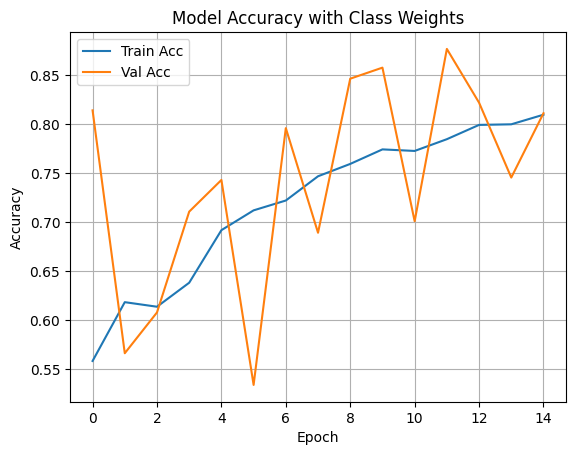


Model saved as 'deepfake_mlp_balanced.h5'


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Step 1: Load dataset
print("Loading dataset...")
X = np.load("X_features.npy")
y = np.load("y_labels.npy")
print(f"Loaded X: {X.shape}, y: {y.shape}")

# Step 2: Split the dataset
print("\nSplitting (80% train, 20% test)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# Step 3: Compute class weights
print("\n⚖️ Computing class weights for imbalance handling...")
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {0: weights[0], 1: weights[1]}
print(f"Class Weights: {class_weights}")

# Step 4: Define the model
print("\n Building MLP model...")
model = Sequential([
    Dense(512, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
print("Model compiled.")

# Step 5: Train the model with class weights
print("\nTraining with class weights...\n")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

# Step 6: Evaluation
print("\nEvaluating model...")
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Step 7: Classification report
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Step 8: Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Step 9: Plot accuracy curve
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy with Class Weights')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Step 10: Save model
model.save("deepfake_mlp_balanced.h5")
print("\nModel saved as 'deepfake_mlp_balanced.h5'")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model.save('/content/drive/MyDrive/DeepFakeProject/Models/deepfake_mlp_balanced.h5')

In [ ]:
!pip install streamlit pyngrok ffmpeg-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 107.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.2 MB/s eta 0:00:00


In [ ]:
!ngrok config add-authtoken 2wi4pjuPwFPNt2ZaVjVdp2RzBBF_6xyjwyRJxSWA7ACNeBK8x

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
%%writefile app.py
import streamlit as st
import os
import subprocess
import numpy as np
from tensorflow.keras.models import load_model

# Paths
BASE = "/content/drive/MyDrive/DeepFakeProject"
MODEL_PATH = f"{BASE}/Models/deepfake_mlp_balanced.h5"
UPLOAD_FOLDER = f"{BASE}/media/uploaded_video"
FRAME_FOLDER = f"{BASE}/media/uploaded_frames"
AUDIO_PATH = f"{BASE}/media/uploaded_audio.wav"

# Create folders
os.makedirs(UPLOAD_FOLDER, exist_ok=True)
os.makedirs(FRAME_FOLDER, exist_ok=True)

# Load model
model = load_model(MODEL_PATH)

st.set_page_config(page_title="DeepFake Detector", layout="centered")

st.markdown("""
    <style>
    body { background-color: #f5f0fb; }
    .main { background-color: #f5f0fb; }
    .stButton > button {
        color: white;
        background-color: #7e57c2;
        border-radius: 8px;
        padding: 0.5em 1em;
        border: none;
        font-size: 1.1em;
    }
    .stFileUploader label {
        color: #6a1b9a;
        font-weight: bold;
    }
    </style>
""", unsafe_allow_html=True)

st.title("Real-Time DeepFake Detection")
st.markdown("Upload a short video to detect if it's real or fake using our trained AI model.")

uploaded_file = st.file_uploader("Upload Video (.mp4)", type=["mp4"])

if uploaded_file:
    video_path = os.path.join(UPLOAD_FOLDER, uploaded_file.name)
    with open(video_path, "wb") as f:
        f.write(uploaded_file.read())

    st.video(video_path)
    st.info("Extracting frames and audio...")

    subprocess.call([
        "ffmpeg", "-i", video_path, "-vf", "fps=1",
        os.path.join(FRAME_FOLDER, "frame_%04d.jpg"),
        "-hide_banner", "-loglevel", "error"
    ])

    subprocess.call([
        "ffmpeg", "-i", video_path, "-q:a", "0", "-map", "a", AUDIO_PATH,
        "-y", "-hide_banner", "-loglevel", "error"
    ])

    # Dummy vector — replace with real audio+visual features
    feature_vector = np.random.rand(1300).reshape(1, -1)

    st.success("Running prediction...")
    score = model.predict(feature_vector)[0][0]

    if score > 0.5:
        st.error(f"Fake video detected. Confidence: {score:.2f}")
    else:
        st.success(f"Real video detected. Confidence: {1 - score:.2f}")

Writing app.py


In [ ]:
from pyngrok import ngrok
!streamlit run app.py &>/content/logs.txt &
public_url = ngrok.connect(8501)
print("Your website is live at:", public_url)

Your website is live at: NgrokTunnel: "https://4603-34-125-211-92.ngrok-free.app" -> "http://localhost:8501"
